In [ ]:
# =====================
# Cell 1: Imports and Configuration
# =====================
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.optimize import minimize
from scipy.special import expit as sigmoid
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

ROOT_DIR = Path(
    "/home/junjiechen/1_work/250401-Dpepalign/Benchmark/Rosetta/interface/Dock/4_GLM/2_combine_af3_train"
)
AF3_PATH = ROOT_DIR / "data/source-nopackinput/af3_rosetta.csv"
ROSETTA_PATH = ROOT_DIR / "data/source-nopackinput/rosetta.csv"
OUTPUT_DIR = ROOT_DIR / "data/train_result/nopackinput_test"

FEATURE_COLUMNS = [
    "dG_separated/dSASAx100",
    "energy_per_intres",
    "dSASA_int_per_res",
]
SOURCE_COLUMN = "source"
TARGET_COLUMN = "target"
LABEL_COLUMN = "label"

N_SPLITS = 5
N_REPEATS = 50
N_FEATURES = len(FEATURE_COLUMNS)
BASE_SEED = 42
C_GRID = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
EPS = 1e-15

SAFE_FEATURE_NAMES = [f.replace("/", "_") for f in FEATURE_COLUMNS]

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "eda").mkdir(parents=True, exist_ok=True)

Dropped 8 rows with missing values.
Removed 1 exact duplicate rows.
AF3 rows: 3210  |  Rosetta rows: 7400
Combined rows (after cleaning): 10601

Rows by source:
source
AF3        3209
Rosetta    7392

Label counts by source:
label       0     1
source             
AF3      1837  1372
Rosetta  5912  1480

Unique targets: 153  (AF3 only: 5,  Rosetta only: 46,  Overlap: 102)

=== Feature Statistics ===
       dG_separated/dSASAx100  energy_per_intres  dSASA_int_per_res
count               10601.000         10601.0000         10601.0000
mean                   -2.014            -1.8573            96.2799
std                     0.954             1.2402            37.4073
min                    -5.470            -4.9050             0.0000
25%                    -2.586            -2.4580            69.7970
50%                    -1.998            -1.9550            92.0100
75%                    -1.492            -1.4000           118.1860
max                     5.988            18.7630     

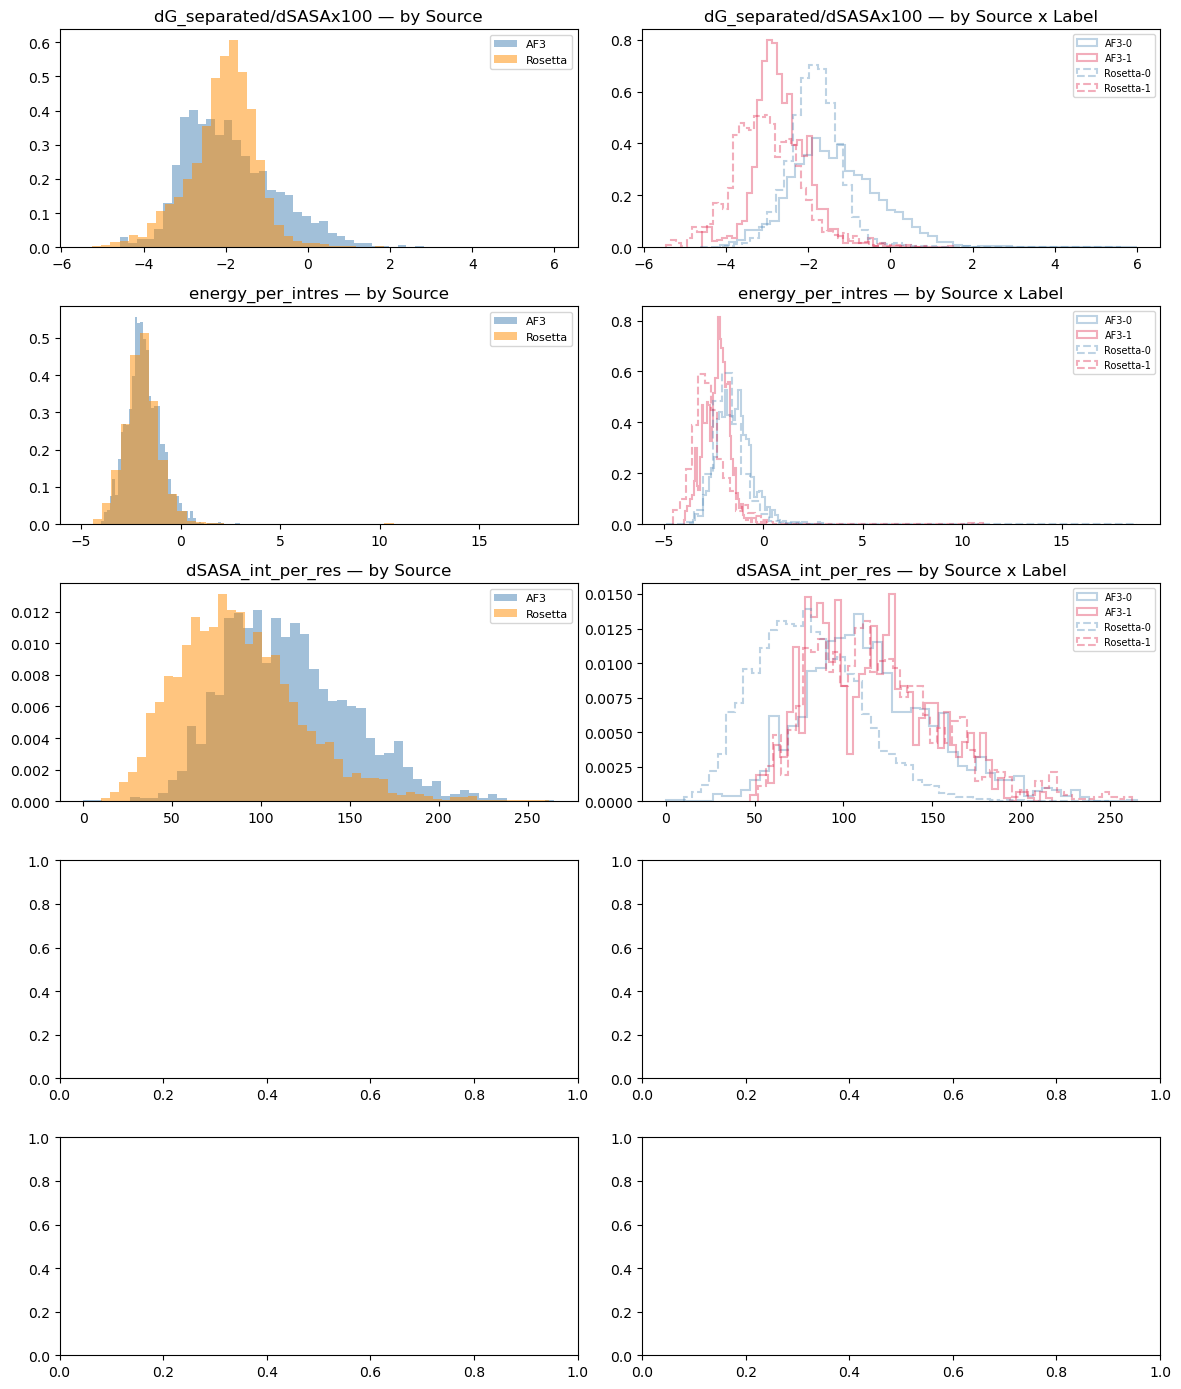

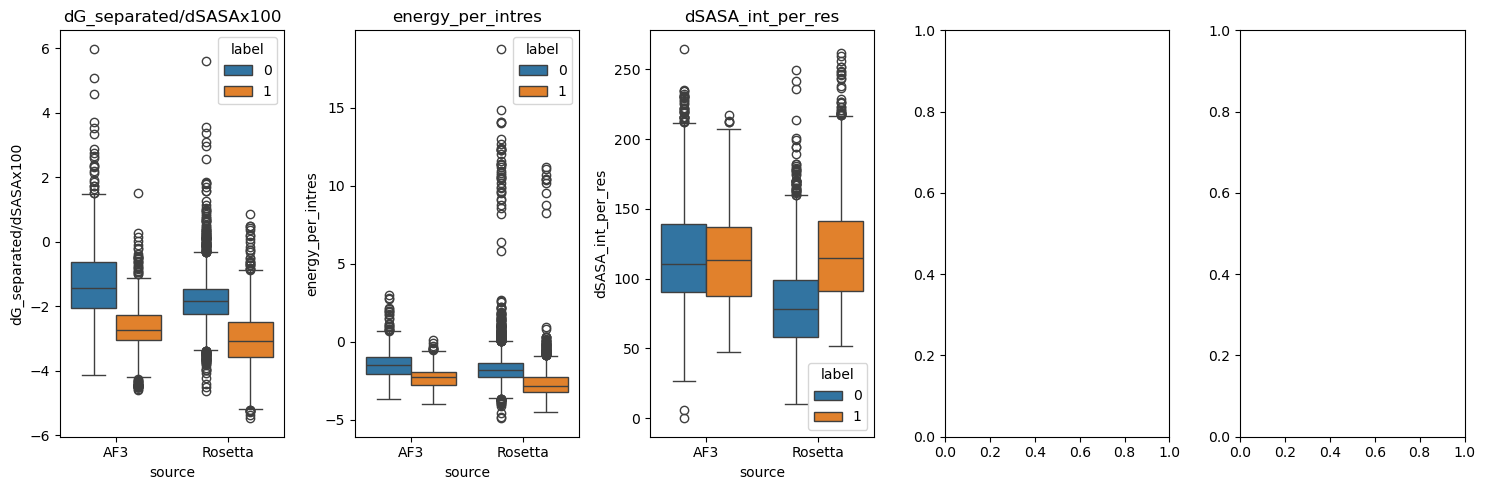

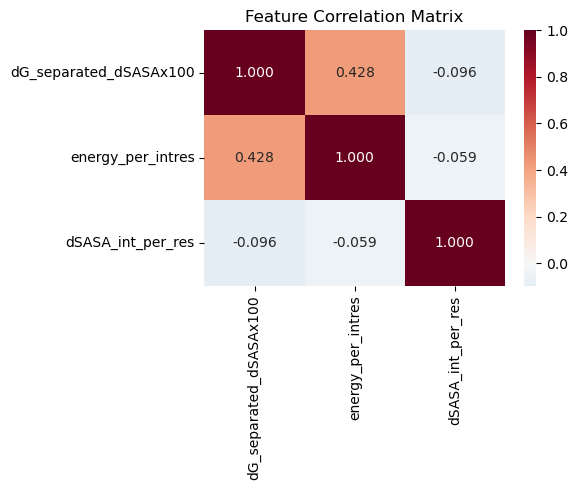

EDA figures saved to: /home/junjiechen/1_work/250401-Dpepalign/Benchmark/Rosetta/interface/Dock/4_GLM/2_combine_af3_train/data/train_result/nopackinput_test/eda


In [ ]:
# =====================
# Cell 2: Data Loading, Cleaning, and Feature Distribution Check
# =====================

# --- 2a. Load and harmonize ---

af3_df = pd.read_csv(AF3_PATH)
af3_df[SOURCE_COLUMN] = "AF3"
af3_df = af3_df[[SOURCE_COLUMN, TARGET_COLUMN, LABEL_COLUMN] + FEATURE_COLUMNS].copy()

rosetta_df = pd.read_csv(ROSETTA_PATH)
rosetta_df[TARGET_COLUMN] = rosetta_df["PDB"].str.split("_").str[0]
rosetta_df = rosetta_df.rename(columns={"energy_int_per_res": "energy_per_intres"})
rosetta_df[SOURCE_COLUMN] = "Rosetta"
rosetta_df = rosetta_df[[SOURCE_COLUMN, TARGET_COLUMN, LABEL_COLUMN] + FEATURE_COLUMNS].copy()

all_df = pd.concat([af3_df, rosetta_df], ignore_index=True)

for col in FEATURE_COLUMNS:
    all_df[col] = pd.to_numeric(all_df[col], errors="coerce")
all_df[LABEL_COLUMN] = pd.to_numeric(all_df[LABEL_COLUMN], errors="coerce")
all_df[TARGET_COLUMN] = all_df[TARGET_COLUMN].astype(str)

initial_len = len(all_df)
all_df = all_df.dropna(subset=[TARGET_COLUMN, LABEL_COLUMN] + FEATURE_COLUMNS)
if (dropped := initial_len - len(all_df)):
    print(f"Dropped {dropped} rows with missing values.")

all_df[LABEL_COLUMN] = all_df[LABEL_COLUMN].astype(int)

dup_mask = all_df.duplicated(subset=[SOURCE_COLUMN, TARGET_COLUMN, LABEL_COLUMN] + FEATURE_COLUMNS)
if (dup_count := int(dup_mask.sum())):
    print(f"Removed {dup_count} exact duplicate rows.")
    # 输出重复行的所有信息到一个csv中
    all_df[dup_mask].to_csv(OUTPUT_DIR / "duplicate_rows.csv", index=False)
    all_df = all_df.loc[~dup_mask]

all_df = all_df.reset_index(drop=True)
model_df = all_df.copy()

# Summary
af3_targets = set(af3_df[TARGET_COLUMN])
rosetta_targets = set(rosetta_df[TARGET_COLUMN])
print(f"AF3 rows: {len(af3_df)}  |  Rosetta rows: {len(rosetta_df)}")
print(f"Combined rows (after cleaning): {len(model_df)}")
print(f"\nRows by source:\n{model_df.groupby(SOURCE_COLUMN).size().to_string()}")
print(f"\nLabel counts by source:\n{model_df.groupby([SOURCE_COLUMN, LABEL_COLUMN]).size().unstack(fill_value=0).to_string()}")
print(f"\nUnique targets: {model_df[TARGET_COLUMN].nunique()}  "
      f"(AF3 only: {len(af3_targets - rosetta_targets)},  "
      f"Rosetta only: {len(rosetta_targets - af3_targets)},  "
      f"Overlap: {len(af3_targets & rosetta_targets)})")

# --- 2b. Feature distribution ---

print(f"\n=== Feature Statistics ===\n{model_df[FEATURE_COLUMNS].describe().round(4).to_string()}")
print(f"\n=== Feature Statistics by Source ===\n{model_df.groupby(SOURCE_COLUMN)[FEATURE_COLUMNS].describe().round(4).to_string()}")

# Histograms: by source and by source x label
fig, axes = plt.subplots(N_FEATURES, 2, figsize=(12, 14))
for i, feat in enumerate(FEATURE_COLUMNS):
    for src, color in [("AF3", "steelblue"), ("Rosetta", "darkorange")]:
        axes[i, 0].hist(model_df.loc[model_df[SOURCE_COLUMN] == src, feat],
                        bins=50, alpha=0.5, label=src, color=color, density=True)
    axes[i, 0].set_title(f"{feat} — by Source")
    axes[i, 0].legend(fontsize=8)

    for src, ls in [("AF3", "-"), ("Rosetta", "--")]:
        for lbl, color in [(0, "steelblue"), (1, "crimson")]:
            axes[i, 1].hist(
                model_df.loc[(model_df[SOURCE_COLUMN] == src) & (model_df[LABEL_COLUMN] == lbl), feat],
                bins=50, alpha=0.35, density=True,
                label=f"{src}-{lbl}", color=color, linestyle=ls,
                histtype="step", linewidth=1.5,
            )
    axes[i, 1].set_title(f"{feat} — by Source x Label")
    axes[i, 1].legend(fontsize=7)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda/feature_histograms.png", dpi=300)
plt.show()

# Boxplots
fig, axes = plt.subplots(1, N_FEATURES, figsize=(15, 5))
for i, feat in enumerate(FEATURE_COLUMNS):
    sns.boxplot(x=SOURCE_COLUMN, y=feat, hue=LABEL_COLUMN, data=model_df, ax=axes[i])
    axes[i].set_title(feat)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda/feature_boxplots.png", dpi=300)
plt.show()

# Correlation heatmap
fig, ax = plt.subplots(figsize=(6, 5))
corr = model_df[FEATURE_COLUMNS].corr()
sns.heatmap(corr, annot=True, fmt=".3f", cmap="RdBu_r", center=0, ax=ax,
            xticklabels=SAFE_FEATURE_NAMES, yticklabels=SAFE_FEATURE_NAMES)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda/correlation_heatmap.png", dpi=300)
plt.show()
print(f"EDA figures saved to: {OUTPUT_DIR / 'eda'}")

X_all = model_df[FEATURE_COLUMNS].copy()
y_all = model_df[LABEL_COLUMN].astype(int).to_numpy()

In [12]:
# =====================
# Cell 3: Utility Functions
# =====================


# --- F1-based threshold ---

def compute_f1_threshold(y_true: np.ndarray, y_prob: np.ndarray):
    """Find the probability threshold that maximizes F1 on the PR curve."""
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    if len(thresholds) == 0:
        return 0.5, float(precision[-1]), float(recall[-1]), 0.0
    prec = precision[1:]
    rec = recall[1:]
    f1_scores = 2 * prec * rec / np.maximum(prec + rec, EPS)
    best = int(np.argmax(f1_scores))
    return float(thresholds[best]), float(prec[best]), float(rec[best]), float(f1_scores[best])


# --- Evaluation ---

def evaluate_probability_predictions(y_true: np.ndarray, y_prob: np.ndarray) -> dict:
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)
    if len(np.unique(y_true)) < 2:
        raise ValueError("Both classes required for ROC-AUC and PR-AUC.")

    roc_auc = float(roc_auc_score(y_true, y_prob))
    pr_auc = float(average_precision_score(y_true, y_prob))

    best_threshold, best_precision, best_recall, best_f1 = compute_f1_threshold(y_true, y_prob)

    y_pred = (y_prob >= best_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "best_threshold": best_threshold,
        "best_precision": best_precision,
        "best_recall": best_recall,
        "best_f1": best_f1,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }


# --- Sample weights ---

def compute_sample_weights(y: np.ndarray) -> np.ndarray:
    y = np.asarray(y, dtype=int)
    class_counts = pd.Series(y).value_counts().to_dict()
    n_samples = float(len(y))
    n_classes = float(len(class_counts))
    return np.asarray([n_samples / (n_classes * class_counts[label]) for label in y])


# --- Model builder (sklearn) ---

def build_sklearn_model(random_state: int, C: float) -> Pipeline:
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=2000, solver="lbfgs", penalty="l2",
            C=C, random_state=random_state,
        )),
    ])


# --- Custom L-BFGS logistic regression with loss tracking ---

def _logistic_loss_and_grad(params: np.ndarray, X: np.ndarray, y: np.ndarray, C: float):
    n_features = X.shape[1]
    w = params[:n_features]
    b = params[n_features]
    z = np.clip(X @ w + b, -500, 500)
    p = sigmoid(z)
    p = np.clip(p, EPS, 1 - EPS)
    n = len(y)
    loss = -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p)) + 0.5 / C * np.sum(w ** 2)
    error = p - y
    dw = X.T @ error / n + w / C
    db = np.mean(error)
    return loss, np.concatenate([dw, [db]])


def fit_logistic_lbfgs(X, y, C=1.0, max_iter=1000, X_val=None, y_val=None):
    """Fit logistic regression via L-BFGS-B, tracking train/val loss per iteration."""
    X_np = np.asarray(X, dtype=float)
    y_np = np.asarray(y, dtype=float)
    n_features = X_np.shape[1]

    train_losses = []
    val_losses = []
    has_val = X_val is not None and y_val is not None

    def callback(params):
        tr_loss, _ = _logistic_loss_and_grad(params, X_np, y_np, C)
        train_losses.append(tr_loss)
        if has_val:
            vl_loss, _ = _logistic_loss_and_grad(params, X_val, y_val, C)
            val_losses.append(vl_loss)

    result = minimize(
        fun=lambda p: _logistic_loss_and_grad(p, X_np, y_np, C),
        x0=np.zeros(n_features + 1),
        jac=True,
        method="L-BFGS-B",
        options={"maxiter": max_iter, "gtol": 1e-5},
        callback=callback,
    )

    w = result.x[:n_features]
    b = result.x[n_features]
    return w, b, train_losses, val_losses


# --- Parameter extraction ---

def extract_raw_parameters(model: Pipeline):
    scaler = model.named_steps["scaler"]
    clf = model.named_steps["clf"]
    std_coef = np.asarray(clf.coef_[0])
    std_intercept = float(clf.intercept_[0])
    scale = np.asarray(scaler.scale_)
    mean = np.asarray(scaler.mean_)
    raw_coef = std_coef / scale
    raw_intercept = std_intercept - float(np.sum((std_coef * mean) / scale))
    return raw_coef, raw_intercept, std_coef, std_intercept


# --- Formula formatting ---

def format_glm_formula(feature_names, coefficients, bias):
    terms = [f"({bias:.6f})"]
    for name, coef in zip(feature_names, coefficients):
        terms.append(f"({coef:.6f}) * {name}")
    return "logit = " + " + ".join(terms) + "\nprobability = 1 / (1 + exp(-logit))"


# --- Fold splitting utilities ---

def summarize_fold_distribution(df: pd.DataFrame, fold_assignment: np.ndarray) -> pd.DataFrame:
    rows = []
    for fold_idx in range(N_SPLITS):
        fold_df = df.loc[fold_assignment == fold_idx]
        pos = int((fold_df[LABEL_COLUMN] == 1).sum())
        neg = int((fold_df[LABEL_COLUMN] == 0).sum())
        af3 = int((fold_df[SOURCE_COLUMN] == "AF3").sum())
        ros = int((fold_df[SOURCE_COLUMN] == "Rosetta").sum())
        rows.append({
            "fold": fold_idx, "n_samples": len(fold_df),
            "n_targets": int(fold_df[TARGET_COLUMN].nunique()),
            "n_pos": pos, "n_neg": neg, "n_af3": af3, "n_rosetta": ros,
            "label_gap": abs(pos - neg), "source_gap": abs(af3 - ros),
            "has_both_labels": pos > 0 and neg > 0,
            "has_both_sources": af3 > 0 and ros > 0,
        })
    return pd.DataFrame(rows)


PURE_FOLD_PENALTY = 1_000_000.0


def fold_quality_score(fold_summary: pd.DataFrame, total_rows: int) -> float:
    size_target = total_rows / N_SPLITS
    size_gap = float((fold_summary["n_samples"] - size_target).abs().sum())
    label_gap = float(fold_summary["label_gap"].sum())
    source_gap = float(fold_summary["source_gap"].sum())
    pure_label = PURE_FOLD_PENALTY * (~fold_summary["has_both_labels"]).sum()
    pure_source = PURE_FOLD_PENALTY * (~fold_summary["has_both_sources"]).sum()
    return size_gap + label_gap + source_gap + pure_label + pure_source


def build_source_balanced_split(df, seed, n_splits=N_SPLITS, max_attempts=50):
    strata = df[SOURCE_COLUMN].astype(str) + "__" + df[LABEL_COLUMN].astype(int).astype(str)
    groups = df[TARGET_COLUMN].astype(str).to_numpy()

    best_assign = None
    best_summary = None
    best_score = float("inf")
    best_seed = seed
    best_attempts = 1

    for attempt in range(max_attempts):
        attempt_seed = seed + attempt * 7919
        splitter = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=attempt_seed)
        fold_assign = np.full(len(df), -1, dtype=int)
        for fold_idx, (_, test_idx) in enumerate(splitter.split(np.zeros(len(df)), strata, groups)):
            fold_assign[test_idx] = fold_idx

        if (fold_assign < 0).any():
            raise RuntimeError("Fold assignment incomplete.")

        summary = summarize_fold_distribution(df, fold_assign)
        score = fold_quality_score(summary, len(df))

        if score < best_score:
            best_score = score
            best_assign = fold_assign.copy()
            best_summary = summary.copy()
            best_seed = attempt_seed
            best_attempts = attempt + 1

        if summary["has_both_labels"].all() and summary["has_both_sources"].all():
            return best_assign, best_summary, best_attempts, best_seed, best_score

    return best_assign, best_summary, best_attempts, best_seed, best_score


# --- Single-feature CV evaluator ---

def evaluate_single_feature_oof(X, y, feature_idx, C, random_state):
    """Run 5-fold stratified CV for a single feature, return OOF probs + metrics."""
    feature_name = FEATURE_COLUMNS[feature_idx]
    X_single = X[[feature_name]]
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=random_state)
    oof = np.full(len(y), np.nan)
    for train_idx, test_idx in skf.split(X_single, y):
        X_tr, X_te = X_single.iloc[train_idx], X_single.iloc[test_idx]
        y_tr = y[train_idx]
        w = compute_sample_weights(y_tr)
        m = LogisticRegression(C=C, max_iter=2000, solver="lbfgs", penalty="l2", random_state=random_state)
        m.fit(X_tr, y_tr, sample_weight=w)
        oof[test_idx] = m.predict_proba(X_te)[:, 1]
    return oof, evaluate_probability_predictions(y, oof)

Grid search for C over [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

Best C = 1.0  (mean ROC-AUC = 0.9001)
       C  mean_roc_auc  std_roc_auc
   0.001      0.893011     0.010663
   0.010      0.899312     0.010069
   0.100      0.900072     0.010151
   1.000      0.900078     0.010208
  10.000      0.900071     0.010217
 100.000      0.900070     0.010215
1000.000      0.900071     0.010216


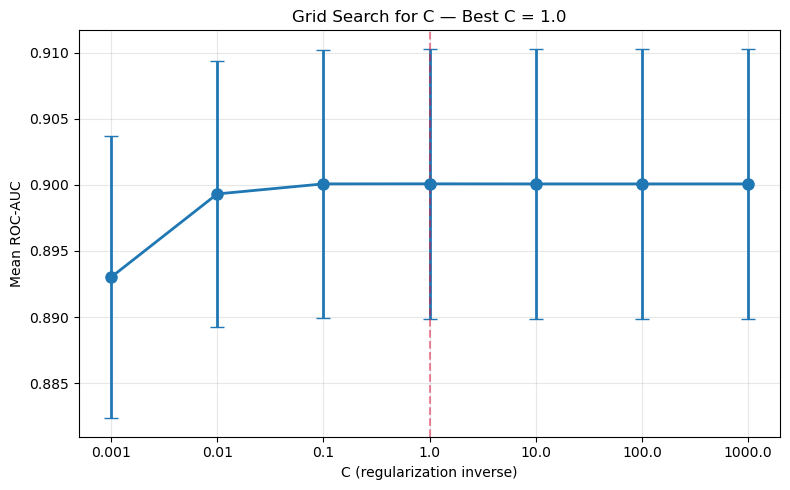

In [13]:
# =====================
# Cell 4: Grid Search for Regularization Strength C
# =====================

print("Grid search for C over", C_GRID)
grid_results = []
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=BASE_SEED)

for C_val in C_GRID:
    fold_aucs = []
    for train_idx, test_idx in skf.split(X_all, y_all):
        X_tr, X_te = X_all.iloc[train_idx], X_all.iloc[test_idx]
        y_tr, y_te = y_all[train_idx], y_all[test_idx]
        w = compute_sample_weights(y_tr)
        model = build_sklearn_model(random_state=BASE_SEED, C=C_val)
        model.fit(X_tr, y_tr, clf__sample_weight=w)
        prob = model.predict_proba(X_te)[:, 1]
        if len(np.unique(y_te)) >= 2:
            fold_aucs.append(roc_auc_score(y_te, prob))
    grid_results.append({
        "C": C_val,
        "mean_roc_auc": np.mean(fold_aucs),
        "std_roc_auc": np.std(fold_aucs, ddof=1),
    })

grid_df = pd.DataFrame(grid_results)
best_C = grid_df.loc[grid_df["mean_roc_auc"].idxmax(), "C"]
print(f"\nBest C = {best_C}  (mean ROC-AUC = {grid_df['mean_roc_auc'].max():.4f})")
print(grid_df.to_string(index=False))

grid_df.to_csv(OUTPUT_DIR / "c_grid_search.csv", index=False)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(range(len(C_GRID)), grid_df["mean_roc_auc"], yerr=grid_df["std_roc_auc"],
            fmt="o-", capsize=5, linewidth=2, markersize=8)
ax.set_xticks(range(len(C_GRID)))
ax.set_xticklabels([str(c) for c in C_GRID])
ax.set_xlabel("C (regularization inverse)")
ax.set_ylabel("Mean ROC-AUC")
ax.set_title(f"Grid Search for C — Best C = {best_C}")
ax.axvline(x=grid_df["mean_roc_auc"].idxmax(), color="crimson", linestyle="--", alpha=0.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "c_grid_search.png", dpi=300)
plt.show()

In [14]:
# =====================
# Cell 5: Repeated 5-Fold CV with Loss Tracking
# =====================

print(f"Running {N_REPEATS} repeated {N_SPLITS}-fold CV with best_C = {best_C} ...\n")

repeat_summary_rows = []
repeat_parameter_rows = []
repeat_oof_matrix = np.empty((N_REPEATS, len(model_df)), dtype=float)
loss_records = []

for repeat_idx in range(N_REPEATS):
    repeat_seed = BASE_SEED + repeat_idx
    fold_assignment, fold_summary, attempts, split_seed, split_score = \
        build_source_balanced_split(model_df, seed=repeat_seed)

    repeat_oof = np.full(len(model_df), np.nan, dtype=float)
    fold_raw_coefs, fold_std_coefs = [], []
    fold_raw_intercepts, fold_std_intercepts = [], []

    for fold_idx in range(N_SPLITS):
        test_mask = fold_assignment == fold_idx
        train_mask = ~test_mask

        X_train_raw = X_all.loc[train_mask].to_numpy(dtype=float)
        y_train = y_all[train_mask]
        X_test_raw = X_all.loc[test_mask].to_numpy(dtype=float)
        y_test = y_all[test_mask]

        # Standardize manually for the custom L-BFGS fit
        tr_mean = X_train_raw.mean(axis=0)
        tr_std = X_train_raw.std(axis=0, ddof=0)
        tr_std = np.where(tr_std == 0, 1.0, tr_std)
        X_train_scaled = (X_train_raw - tr_mean) / tr_std
        X_test_scaled = (X_test_raw - tr_mean) / tr_std

        w_scaled, b_scaled, train_losses, val_losses = fit_logistic_lbfgs(
            X_train_scaled, y_train, C=best_C, max_iter=1000,
            X_val=X_test_scaled, y_val=y_test,
        )

        # Record loss history
        for it, (tr_loss, vl_loss) in enumerate(zip(train_losses, val_losses)):
            loss_records.append({
                "repeat": repeat_idx + 1, "fold": fold_idx,
                "iteration": it, "train_loss": tr_loss, "val_loss": vl_loss,
            })

        # Convert to raw-space coefficients
        w_raw = w_scaled / tr_std
        b_raw = b_scaled - float(np.sum(w_scaled * tr_mean / tr_std))

        # OOF predictions (raw space)
        fold_prob = sigmoid(np.clip(X_test_raw @ w_raw + b_raw, -500, 500))
        repeat_oof[test_mask] = fold_prob

        fold_raw_coefs.append(w_raw)
        fold_std_coefs.append(w_scaled)
        fold_raw_intercepts.append(b_raw)
        fold_std_intercepts.append(b_scaled)

    repeat_oof_matrix[repeat_idx] = repeat_oof

    # Repeat-level evaluation
    repeat_eval = evaluate_probability_predictions(y_all, repeat_oof)
    split_ok = bool(fold_summary["has_both_labels"].all() and fold_summary["has_both_sources"].all())

    repeat_summary_rows.append({
        "repeat": repeat_idx + 1, "seed": repeat_seed,
        "split_seed": split_seed, "split_attempts": attempts,
        "split_ok": split_ok,
        "roc_auc": repeat_eval["roc_auc"],
        "pr_auc": repeat_eval["pr_auc"],
        "best_threshold": repeat_eval["best_threshold"],
        "best_f1": repeat_eval["best_f1"],
        "accuracy": repeat_eval["accuracy"],
        "balanced_accuracy": repeat_eval["balanced_accuracy"],
        "precision": repeat_eval["precision"],
        "recall": repeat_eval["recall"],
        "f1": repeat_eval["f1"],
        "tn": repeat_eval["tn"], "fp": repeat_eval["fp"],
        "fn": repeat_eval["fn"], "tp": repeat_eval["tp"],
    })

    repeat_parameter_rows.append({
        "repeat": repeat_idx + 1,
        "raw_bias_mean": float(np.mean(fold_raw_intercepts)),
        "std_bias_mean": float(np.mean(fold_std_intercepts)),
        **{f"raw_coef_mean_{sn}": float(np.mean(vals))
           for sn, vals in zip(SAFE_FEATURE_NAMES, np.stack(fold_raw_coefs, axis=0).T)},
        **{f"std_coef_mean_{sn}": float(np.mean(vals))
           for sn, vals in zip(SAFE_FEATURE_NAMES, np.stack(fold_std_coefs, axis=0).T)},
    })

    if (repeat_idx + 1) % 10 == 0 or repeat_idx == 0:
        print(f"Repeat {repeat_idx + 1}/{N_REPEATS}: "
              f"ROC-AUC={repeat_eval['roc_auc']:.4f}, "
              f"PR-AUC={repeat_eval['pr_auc']:.4f}, "
              f"threshold={repeat_eval['best_threshold']:.4f}, "
              f"split_ok={split_ok}, attempts={attempts}")

repeat_summary_df = pd.DataFrame(repeat_summary_rows)
repeat_parameter_df = pd.DataFrame(repeat_parameter_rows)
loss_df = pd.DataFrame(loss_records)

print(f"\nCompleted {len(repeat_summary_df)} repeats. "
      f"Total loss records: {len(loss_df)}")
loss_df.to_csv(OUTPUT_DIR / "loss_history.csv", index=False)

Running 50 repeated 5-fold CV with best_C = 1.0 ...

Repeat 1/50: ROC-AUC=0.8833, PR-AUC=0.7547, threshold=0.2991, split_ok=True, attempts=1
Repeat 10/50: ROC-AUC=0.8843, PR-AUC=0.7570, threshold=0.2970, split_ok=True, attempts=1
Repeat 20/50: ROC-AUC=0.8810, PR-AUC=0.7455, threshold=0.2994, split_ok=True, attempts=1
Repeat 30/50: ROC-AUC=0.8799, PR-AUC=0.7442, threshold=0.2918, split_ok=True, attempts=1
Repeat 40/50: ROC-AUC=0.8840, PR-AUC=0.7570, threshold=0.2940, split_ok=True, attempts=1
Repeat 50/50: ROC-AUC=0.8851, PR-AUC=0.7576, threshold=0.3014, split_ok=True, attempts=1

Completed 50 repeats. Total loss records: 1753


Repeated CV summary (mean ± std across 50 repeats):
      roc_auc  pr_auc  best_threshold  best_f1
mean   0.8828  0.7541          0.2997   0.7107
std    0.0019  0.0040          0.0038   0.0039

All splits valid: True

Aggregate mean-OOF metrics:
  roc_auc: 0.884131
  pr_auc: 0.756514
  best_threshold: 0.302905
  best_precision: 0.707182
  best_recall: 0.718093
  best_f1: 0.712596
  accuracy: 0.844071
  balanced_accuracy: 0.804265
  precision: 0.706938
  recall: 0.718093
  f1: 0.712472


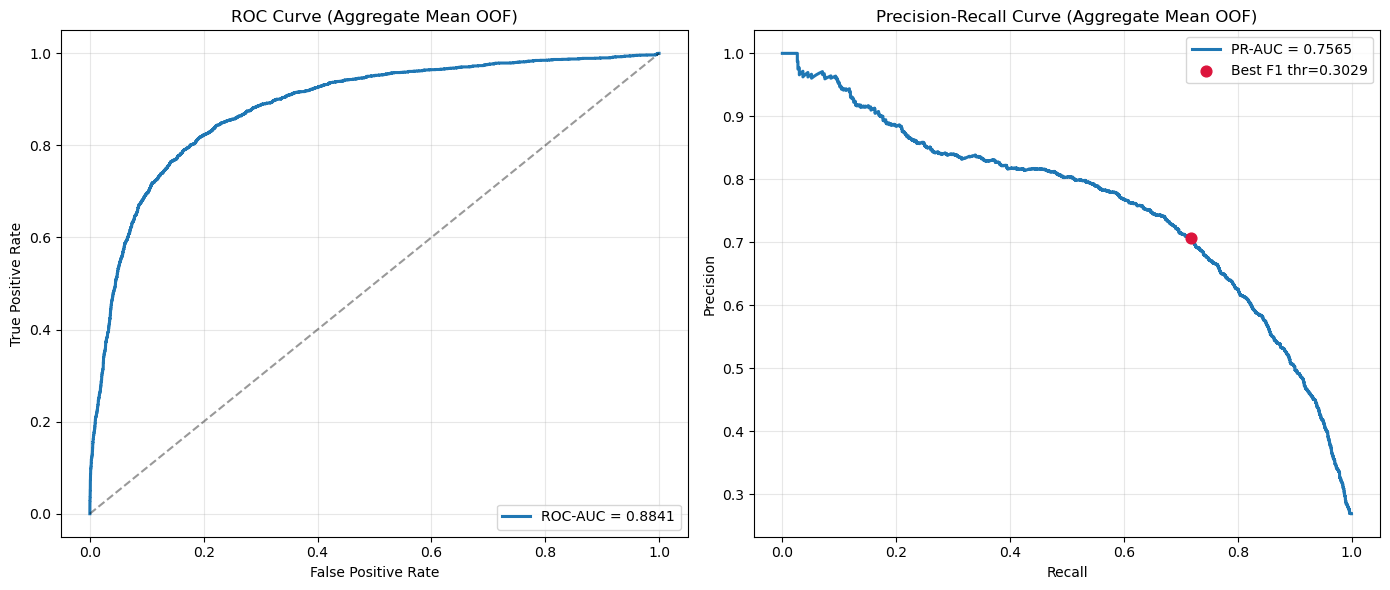

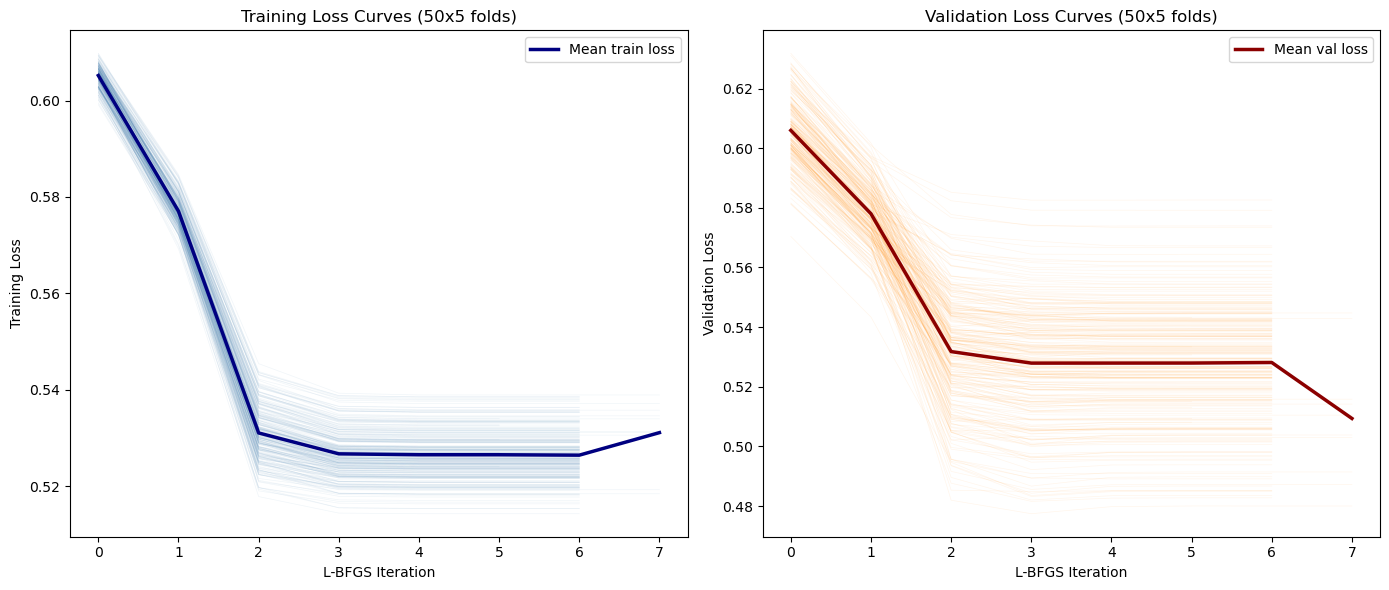


Figures saved to: /home/junjiechen/1_work/250401-Dpepalign/Benchmark/Rosetta/interface/Dock/4_GLM/2_combine_af3_train/data/train_result/nopackinput_5feature


In [15]:
# =====================
# Cell 6: Aggregate Evaluation and Loss Curves
# =====================

mean_oof_prob = repeat_oof_matrix.mean(axis=0)
std_oof_prob = repeat_oof_matrix.std(axis=0, ddof=1)

aggregate_eval = evaluate_probability_predictions(y_all, mean_oof_prob)

# Save CSVs
prediction_summary_df = model_df[[SOURCE_COLUMN, TARGET_COLUMN, LABEL_COLUMN]].copy()
prediction_summary_df["mean_oof_prob"] = mean_oof_prob
prediction_summary_df["std_oof_prob"] = std_oof_prob
prediction_summary_df["mean_oof_pred"] = (mean_oof_prob >= aggregate_eval["best_threshold"]).astype(int)

repeat_summary_df.to_csv(OUTPUT_DIR / "repeat_cv_summary.csv", index=False)
prediction_summary_df.to_csv(OUTPUT_DIR / "repeat_oof_predictions.csv", index=False)
repeat_parameter_df.to_csv(OUTPUT_DIR / "repeat_parameter_summary.csv", index=False)
pd.DataFrame([aggregate_eval]).to_csv(OUTPUT_DIR / "aggregate_oof_summary.csv", index=False)

# --- QC Summary ---
print("Repeated CV summary (mean ± std across 50 repeats):")
print(repeat_summary_df[["roc_auc", "pr_auc", "best_threshold", "best_f1"]].agg(["mean", "std"]).round(4))
print(f"\nAll splits valid: {repeat_summary_df['split_ok'].all()}")
print(f"\nAggregate mean-OOF metrics:")
for k, v in aggregate_eval.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.6f}")

# --- Plot 1: Combined ROC + PR curves from aggregate OOF ---
fpr, tpr, _ = roc_curve(y_all, mean_oof_prob)
precision, recall, _ = precision_recall_curve(y_all, mean_oof_prob)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.plot(fpr, tpr, linewidth=2.2, label=f"ROC-AUC = {aggregate_eval['roc_auc']:.4f}")
ax1.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curve (Aggregate Mean OOF)")
ax1.legend(loc="lower right")
ax1.grid(True, alpha=0.3)

ax2.plot(recall, precision, linewidth=2.2, label=f"PR-AUC = {aggregate_eval['pr_auc']:.4f}")
ax2.scatter([aggregate_eval["best_recall"]], [aggregate_eval["best_precision"]],
            color="crimson", s=60, zorder=3,
            label=f"Best F1 thr={aggregate_eval['best_threshold']:.4f}")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curve (Aggregate Mean OOF)")
ax2.legend(loc="best")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "aggregate_roc_pr_curves.png", dpi=300)
plt.show()

# --- Plot 2: Combined Loss Curves ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for (rep, fold), grp in loss_df.groupby(["repeat", "fold"]):
    ax1.plot(grp["iteration"], grp["train_loss"], alpha=0.08, linewidth=0.5, color="steelblue")
    ax2.plot(grp["iteration"], grp["val_loss"], alpha=0.08, linewidth=0.5, color="darkorange")

mean_train = loss_df.groupby("iteration")["train_loss"].mean()
mean_val = loss_df.groupby("iteration")["val_loss"].mean()
ax1.plot(mean_train.index, mean_train.values, color="navy", linewidth=2.5, label="Mean train loss")
ax2.plot(mean_val.index, mean_val.values, color="darkred", linewidth=2.5, label="Mean val loss")

ax1.set_xlabel("L-BFGS Iteration")
ax1.set_ylabel("Training Loss")
ax1.set_title(f"Training Loss Curves ({N_REPEATS}x{N_SPLITS} folds)")
ax1.legend()

ax2.set_xlabel("L-BFGS Iteration")
ax2.set_ylabel("Validation Loss")
ax2.set_title(f"Validation Loss Curves ({N_REPEATS}x{N_SPLITS} folds)")
ax2.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "loss_curves.png", dpi=300)
plt.show()

print(f"\nFigures saved to: {OUTPUT_DIR}")

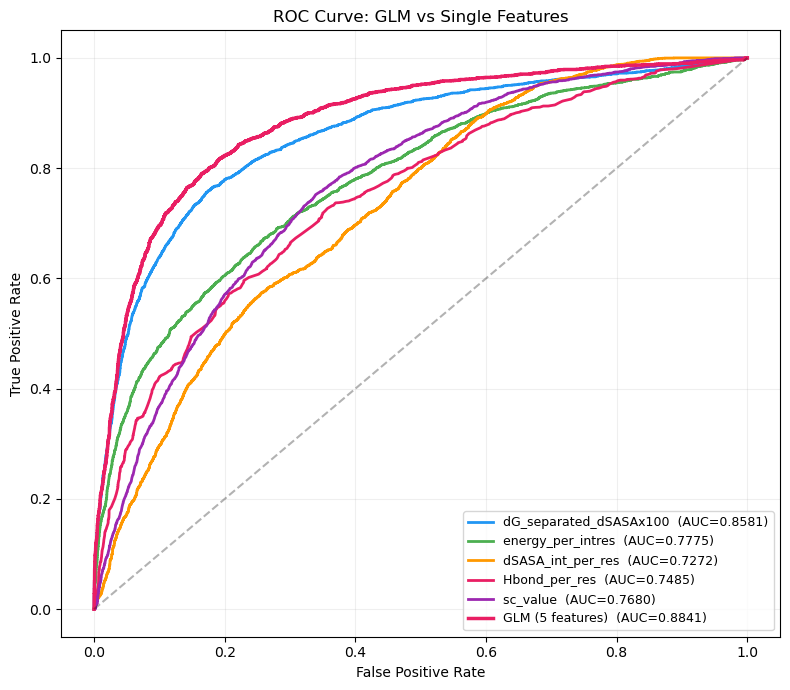

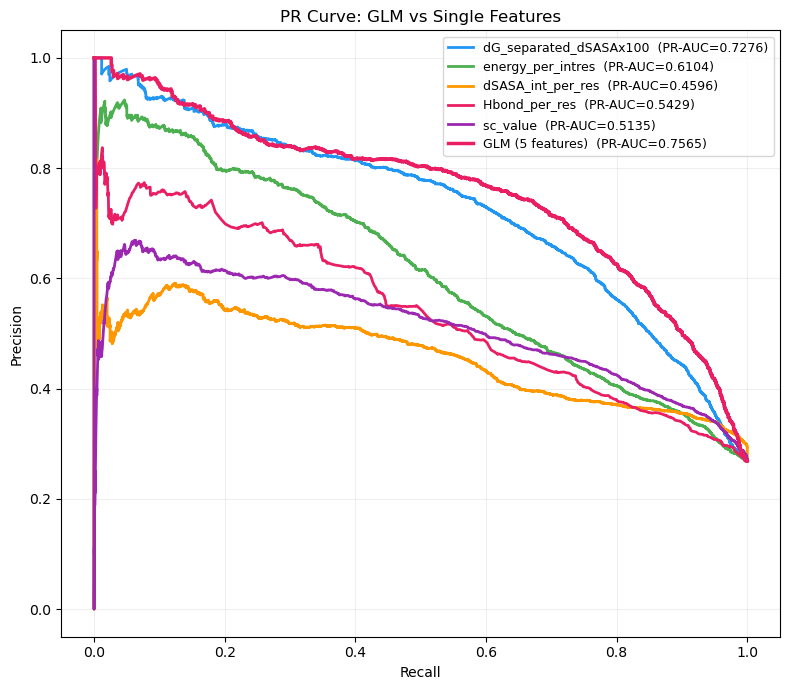


Model Comparison:
                 Model  ROC-AUC  PR-AUC  Best F1  Accuracy  Balanced Acc
dG_separated_dSASAx100   0.8581  0.7276   0.6818    0.8154        0.7897
     energy_per_intres   0.7775  0.6104   0.5654    0.7218        0.7062
     dSASA_int_per_res   0.7272  0.4596   0.5112    0.5420        0.6519
         Hbond_per_res   0.7485  0.5429   0.5389    0.6649        0.6847
              sc_value   0.7680  0.5135   0.5625    0.6849        0.7063
      GLM (5 features)   0.8841  0.7565   0.7126    0.8441        0.8043


In [17]:
# =====================
# Cell 7: GLM vs Single-Feature Comparison
# =====================

colors = ["#2196F3", "#4CAF50", "#FF9800", "#E91E63", "#9C27B0", "#607D8B"]
feature_labels = SAFE_FEATURE_NAMES + ["GLM (all 5 features)"]

# Train single-feature models via 5-fold CV
single_results = {}
for i, feat in enumerate(FEATURE_COLUMNS):
    oof, metrics = evaluate_single_feature_oof(X_all, y_all, i, C=best_C, random_state=BASE_SEED)
    single_results[feat] = {"oof": oof, **metrics}

# Full GLM uses mean OOF from repeated CV
glm_oof = mean_oof_prob

# --- ROC Comparison ---
fig, ax = plt.subplots(figsize=(8, 7))
for i, feat in enumerate(FEATURE_COLUMNS):
    fpr, tpr, _ = roc_curve(y_all, single_results[feat]["oof"])
    ax.plot(fpr, tpr, linewidth=2, color=colors[i],
            label=f"{SAFE_FEATURE_NAMES[i]}  (AUC={single_results[feat]['roc_auc']:.4f})")

fpr_glm, tpr_glm, _ = roc_curve(y_all, glm_oof)
ax.plot(fpr_glm, tpr_glm, linewidth=2.5, color=colors[3],
        label=f"GLM (5 features)  (AUC={aggregate_eval['roc_auc']:.4f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve: GLM vs Single Features")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "glm_vs_single_roc.png", dpi=300)
plt.show()

# --- PR Comparison ---
fig, ax = plt.subplots(figsize=(8, 7))
for i, feat in enumerate(FEATURE_COLUMNS):
    prec, rec, _ = precision_recall_curve(y_all, single_results[feat]["oof"])
    ax.plot(rec, prec, linewidth=2, color=colors[i],
            label=f"{SAFE_FEATURE_NAMES[i]}  (PR-AUC={single_results[feat]['pr_auc']:.4f})")

prec_glm, rec_glm, _ = precision_recall_curve(y_all, glm_oof)
ax.plot(rec_glm, prec_glm, linewidth=2.5, color=colors[3],
        label=f"GLM (5 features)  (PR-AUC={aggregate_eval['pr_auc']:.4f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("PR Curve: GLM vs Single Features")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "glm_vs_single_pr.png", dpi=300)
plt.show()

# --- Comparison table ---
comparison_rows = []
for i, feat in enumerate(FEATURE_COLUMNS):
    r = single_results[feat]
    comparison_rows.append({
        "Model": SAFE_FEATURE_NAMES[i],
        "ROC-AUC": r["roc_auc"],
        "PR-AUC": r["pr_auc"],
        "Best F1": r["best_f1"],
        "Accuracy": r["accuracy"],
        "Balanced Acc": r["balanced_accuracy"],
    })
comparison_rows.append({
    "Model": "GLM (5 features)",
    "ROC-AUC": aggregate_eval["roc_auc"],
    "PR-AUC": aggregate_eval["pr_auc"],
    "Best F1": aggregate_eval["best_f1"],
    "Accuracy": aggregate_eval["accuracy"],
    "Balanced Acc": aggregate_eval["balanced_accuracy"],
})

comparison_df = pd.DataFrame(comparison_rows)
print("\nModel Comparison:")
print(comparison_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

In [ ]:
# =====================
# Cell 8: Final Model Training and Formula Export
# =====================

# Train final model on all data
final_model = build_sklearn_model(random_state=BASE_SEED, C=best_C)
final_model.fit(X_all, y_all, clf__sample_weight=compute_sample_weights(y_all))

raw_coef, raw_bias, std_coef, std_bias = extract_raw_parameters(final_model)

# Parameter report
final_param_df = pd.DataFrame({
    "term": ["bias"] + FEATURE_COLUMNS,
    "raw_coefficient": [raw_bias] + list(raw_coef),
    "standardized_coefficient": [std_bias] + list(std_coef),
})

repeat_param_stats_df = (
    repeat_parameter_df.drop(columns=["repeat"])
    .agg(["mean", "std"]).T
    .reset_index().rename(columns={"index": "term"})
)

# Build formula
formula_text = format_glm_formula(FEATURE_COLUMNS, raw_coef, raw_bias)
threshold_text = (
    f"Best threshold from repeated CV mean OOF PR curve: {aggregate_eval['best_threshold']:.6f}\n"
    f"Best F1: {aggregate_eval['best_f1']:.6f}\n"
    f"Precision: {aggregate_eval['best_precision']:.6f}\n"
    f"Recall: {aggregate_eval['best_recall']:.6f}\n"
    f"ROC-AUC: {aggregate_eval['roc_auc']:.6f}\n"
    f"PR-AUC: {aggregate_eval['pr_auc']:.6f}\n"
    f"C (regularization): {best_C}"
)

report_text = "\n".join([
    "Final GLM Formula:",
    formula_text,
    "",
    "Threshold & Performance:",
    threshold_text,
    "",
    "Final Parameters:",
    final_param_df.to_string(index=False),
    "",
    "Parameter Stability (mean ± std across 50 repeats):",
    repeat_param_stats_df.to_string(index=False),
])

(OUTPUT_DIR / "final_glm_report.txt").write_text(report_text, encoding="utf-8")
final_param_df.to_csv(OUTPUT_DIR / "final_glm_parameters.csv", index=False)
repeat_param_stats_df.to_csv(OUTPUT_DIR / "repeat_parameter_stats.csv", index=False)

print(report_text)
print(f"\nReport saved to: {OUTPUT_DIR / 'final_glm_report.txt'}")

Final GLM Formula:
logit = (-7.672311) + (-1.912348) * dG_separated/dSASAx100 + (-0.254079) * energy_per_intres + (0.027576) * dSASA_int_per_res
probability = 1 / (1 + exp(-logit))

Threshold & Performance:
Best threshold from repeated CV mean OOF PR curve: 0.338975
Best F1: 0.733356
Precision: 0.721656
Recall: 0.745442
ROC-AUC: 0.892579
PR-AUC: 0.791020
C (regularization): 10.0

Final Parameters:
                  term  raw_coefficient  standardized_coefficient
                  bias        -7.672311                 -0.693992
dG_separated/dSASAx100        -1.912348                 -1.824272
     energy_per_intres        -0.254079                 -0.315102
     dSASA_int_per_res         0.027576                  1.031509

Parameter Stability (mean ± std across 50 repeats):
                                term      mean      std
                       raw_bias_mean -4.662675 0.005449
                       std_bias_mean -1.228363 0.000429
raw_coef_mean_dG_separated_dSASAx100 -0.805846 0